# FL vs SFL — Non-IID MNIST Comparison with 1, 2, 4, and 6 Labels per Client

This notebook compares **Federated Learning (FL)** and **Split Federated Learning (SFL / Design 1)** on MNIST under several non-IID label-skew settings.

The key experiment is to evaluate the **global model after every communication round** and save one accuracy value per round for both FL and SFL.

The notebook runs four settings:

| Setting | Meaning |
|---|---|
| `labels_per_client = 1` | extreme non-IID; each client sees only one digit |
| `labels_per_client = 2` | strong non-IID |
| `labels_per_client = 4` | moderate non-IID |
| `labels_per_client = 6` | milder non-IID |

The purpose is to show how FL and SFL behave as the client data distribution becomes less extreme.


## 1. Import libraries

This cell imports the Python, PyTorch, TorchVision, NumPy, Pandas, and plotting libraries used in the experiment.


In [1]:
import os
import copy
import time
import random
from collections import OrderedDict, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


## 2. Reproducibility and device setup

This cell fixes random seeds so that repeated runs are easier to compare. It also selects GPU if CUDA is available, otherwise CPU.


In [2]:
def set_seed(seed: int = 42):
    """Set random seeds for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These settings help make CUDA results more deterministic.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 3. Experiment settings and output folders

Change the values in this cell to control the experiment. By default it runs 50 rounds for 10 clients and compares 1, 2, 4, and 6 labels per client.

The output folders are created automatically.


In [25]:
# MNIST has 10 digit classes, so 10 clients works naturally for label-skew experiments.
NUM_CLIENTS = 10
ROUNDS = 50
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
TEST_BATCH_SIZE = 256

# Run these non-IID severities. 1 label/client is the hardest case.
LABELS_PER_CLIENT_LIST = [1, 2, 4, 6]

# Optimizer settings.
# Use "sgd" or "adam". Adam is often worth comparing when SGD struggles.
OPTIMIZER_NAME = "SGD"
LEARNING_RATE = 0.005

# Optional learning-rate decay.
# Keep USE_LR_DECAY = False for the first Adam test, so the result is easier to interpret.
USE_LR_DECAY = False
LR_DECAY = 0.98


def get_round_lr(round_id: int) -> float:
    """Return the learning rate for this communication round."""
    if USE_LR_DECAY:
        return LEARNING_RATE * (LR_DECAY ** (round_id - 1))
    return LEARNING_RATE


# Set to an integer such as 1000 for a quick debugging run.
# Set to None for the full MNIST training set.
MAX_SAMPLES_PER_CLIENT = None

# Save weights every N rounds. Use 1 to save every round, or 10 to save fewer files.
SAVE_WEIGHTS_EVERY = 1

RESULTS_CSV_DIR = "results/csv"
PLOTS_DIR = "results/plots"
WEIGHTS_BASE_DIR = "results/weights/fl_vs_sfl_noniid_label_skew"

os.makedirs(RESULTS_CSV_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(WEIGHTS_BASE_DIR, exist_ok=True)

print("CSV results will be saved to:", RESULTS_CSV_DIR)
print("Plots will be saved to:", PLOTS_DIR)
print("Weights will be saved under:", WEIGHTS_BASE_DIR)


CSV results will be saved to: results/csv
Plots will be saved to: results/plots
Weights will be saved under: results/weights/fl_vs_sfl_noniid_label_skew


## 4. Load MNIST dataset

This cell downloads MNIST if it is not already available in `./data`. The images are converted to PyTorch tensors.


In [26]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Train samples: 60000
Test samples: 10000


## 5. Create non-IID client datasets

This cell creates the key label-skew partition.

Important design choice: **samples are not duplicated** between clients. For example, if `labels_per_client = 2`, a digit class may appear in two clients, but the samples of that digit are split between those clients.


In [27]:
def get_targets(dataset):
    """Return all labels/targets from a TorchVision dataset."""
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if torch.is_tensor(targets):
            targets = targets.cpu().numpy()
        return np.array(targets)
    return np.array([dataset[i][1] for i in range(len(dataset))])


def build_cyclic_client_label_map(num_clients: int, unique_labels, labels_per_client: int):
    """Assign each client a cyclic set of labels.

    Example for MNIST and labels_per_client=2:
    client 0 -> [0, 1]
    client 1 -> [1, 2]
    ...
    client 9 -> [9, 0]
    """
    labels = list(unique_labels)
    num_labels = len(labels)

    if labels_per_client < 1 or labels_per_client > num_labels:
        raise ValueError("labels_per_client must be between 1 and the number of classes.")

    client_label_map = {}
    for client_id in range(num_clients):
        # Cyclic assignment keeps all clients similarly non-IID.
        client_label_map[client_id] = [labels[(client_id + j) % num_labels] for j in range(labels_per_client)]

    return client_label_map


def create_label_skew_client_subsets(dataset, num_clients: int, labels_per_client: int, seed: int, max_samples_per_client=None):
    """Create non-IID client subsets with a fixed number of labels per client.

    The function first decides which labels each client should receive. Then, for each label,
    it splits that label's samples across all clients that contain that label. This avoids
    duplicate training samples across clients.
    """
    targets = get_targets(dataset)
    unique_labels = sorted(np.unique(targets).tolist())
    rng = np.random.default_rng(seed + labels_per_client * 100)

    client_label_map = build_cyclic_client_label_map(num_clients, unique_labels, labels_per_client)

    # Reverse map: label -> clients that should receive part of this label's data.
    label_to_clients = defaultdict(list)
    for client_id, labels in client_label_map.items():
        for label in labels:
            label_to_clients[label].append(client_id)

    client_indices = {client_id: [] for client_id in range(num_clients)}

    for label in unique_labels:
        label_indices = np.where(targets == label)[0]
        rng.shuffle(label_indices)

        receiving_clients = label_to_clients[label]
        # Split this label's samples across the clients assigned to this label.
        split_indices = np.array_split(label_indices, len(receiving_clients))

        for client_id, part in zip(receiving_clients, split_indices):
            client_indices[client_id].extend(part.tolist())

    subsets = []
    for client_id in range(num_clients):
        indices = np.array(client_indices[client_id])
        rng.shuffle(indices)

        # Optional cap for quick testing. Leave as None for full experiments.
        if max_samples_per_client is not None:
            indices = indices[:max_samples_per_client]

        subsets.append(Subset(dataset, indices.tolist()))

    return subsets, client_label_map


def describe_client_split(client_subsets, client_label_map):
    """Print a compact summary of labels and sample counts per client."""
    for client_id, subset in enumerate(client_subsets):
        print(
            f"Client {client_id + 1:02d}: "
            f"labels={client_label_map[client_id]}, samples={len(subset)}"
        )
    print("Total samples used:", sum(len(subset) for subset in client_subsets))


## 6. Data loaders

This cell creates deterministic loaders. FL and SFL use the same batch order for the same client and round, which helps test whether the FL and SFL implementations are equivalent.


In [28]:
def make_client_loader(client_subsets, client_id: int, round_id: int):
    """Create one DataLoader for one client in one communication round."""
    # Same seed for FL and SFL means both methods see batches in the same order.
    loader_seed = SEED + round_id * 1000 + client_id
    generator = torch.Generator().manual_seed(loader_seed)

    return DataLoader(
        client_subsets[client_id],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )


test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
)


## 7. Define the full model and split model

The full FL model and the combined SFL client/server model have the same architecture. This is important because we want to compare FL and SFL fairly.


In [29]:
class FullModel(nn.Module):
    """Full model used by FL and reconstructed SFL evaluation."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        return self.fc5(x)


class ClientModel(nn.Module):
    """SFL client-side model: first part of the full neural network."""
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        return self.relu2(self.fc2(x))


class ServerModel(nn.Module):
    """SFL server-side model: second part of the full neural network."""
    def __init__(self):
        super().__init__()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 32)
        self.relu4 = nn.ReLU()
        self.fc5 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.relu3(self.fc3(x))
        x = self.relu4(self.fc4(x))
        return self.fc5(x)


## 8. State-dictionary helper functions

These helper functions convert between the full FL model and the split SFL client/server models. They also implement FedAvg and the L2 distance check between FL and reconstructed SFL weights.


In [30]:
def get_state_dict(model: nn.Module):
    """Return a CPU copy of the model parameters."""
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def load_state_dict_to_model(model: nn.Module, state_dict):
    """Load a saved state dictionary into a model."""
    model.load_state_dict(state_dict, strict=True)


def full_to_client_state(full_state):
    """Extract the SFL client-side weights from the full model."""
    return OrderedDict({
        "fc1.weight": full_state["fc1.weight"].clone(),
        "fc1.bias": full_state["fc1.bias"].clone(),
        "fc2.weight": full_state["fc2.weight"].clone(),
        "fc2.bias": full_state["fc2.bias"].clone(),
    })


def full_to_server_state(full_state):
    """Extract the SFL server-side weights from the full model."""
    return OrderedDict({
        "fc3.weight": full_state["fc3.weight"].clone(),
        "fc3.bias": full_state["fc3.bias"].clone(),
        "fc4.weight": full_state["fc4.weight"].clone(),
        "fc4.bias": full_state["fc4.bias"].clone(),
        "fc5.weight": full_state["fc5.weight"].clone(),
        "fc5.bias": full_state["fc5.bias"].clone(),
    })


def split_to_full_state(client_state, server_state):
    """Reconstruct a full-model state dictionary from SFL client and server parts."""
    full_state = OrderedDict()
    full_state["fc1.weight"] = client_state["fc1.weight"].clone()
    full_state["fc1.bias"] = client_state["fc1.bias"].clone()
    full_state["fc2.weight"] = client_state["fc2.weight"].clone()
    full_state["fc2.bias"] = client_state["fc2.bias"].clone()
    full_state["fc3.weight"] = server_state["fc3.weight"].clone()
    full_state["fc3.bias"] = server_state["fc3.bias"].clone()
    full_state["fc4.weight"] = server_state["fc4.weight"].clone()
    full_state["fc4.bias"] = server_state["fc4.bias"].clone()
    full_state["fc5.weight"] = server_state["fc5.weight"].clone()
    full_state["fc5.bias"] = server_state["fc5.bias"].clone()
    return full_state


def fedavg_state_dicts(state_dicts, sample_counts):
    """Weighted FedAvg aggregation using each client's number of samples."""
    total_samples = sum(sample_counts)
    avg_state = OrderedDict()

    for key in state_dicts[0].keys():
        avg_tensor = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for state, n in zip(state_dicts, sample_counts):
            # Weight each client update by its local dataset size.
            avg_tensor += state[key].float() * (n / total_samples)
        avg_state[key] = avg_tensor

    return avg_state


def l2_distance_state_dicts(state_a, state_b):
    """Calculate L2 distance between two model state dictionaries."""
    total_sq = 0.0
    for key in state_a.keys():
        diff = state_a[key].float() - state_b[key].float()
        total_sq += torch.sum(diff ** 2).item()
    return total_sq ** 0.5


## 9. Optimizer helper

This cell lets the same notebook switch between SGD and Adam without rewriting the training functions.


In [31]:
def make_optimizer(parameters, optimizer_name: str, lr: float):
    """Create an optimizer using the selected optimizer name."""
    optimizer_name = optimizer_name.lower()

    if optimizer_name == "sgd":
        return optim.SGD(parameters, lr=lr)

    if optimizer_name == "adam":
        return optim.Adam(parameters, lr=lr)

    raise ValueError("optimizer_name must be either 'sgd' or 'adam'.")


## 10. Evaluation function

This function evaluates the global model on the full MNIST test set after every aggregation round.


In [32]:
@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, device: torch.device):
    """Return average test loss and test accuracy."""
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


## 11. FL client training

Each FL client receives a copy of the global full model, trains locally, and returns the updated full-model weights.


In [33]:
def train_fl_client(start_global_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    """Train one FL client for the configured number of local epochs."""
    model = FullModel().to(device)
    load_state_dict_to_model(model, start_global_state)

    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(model.parameters(), OPTIMIZER_NAME, lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return get_state_dict(model)


## 12. SFL Design 1 client training

This uses the equivalence-focused SFL design: each client has its own client-side model and its own independent server-side copy during the round. After local training, the client-side and server-side states are aggregated separately.


In [34]:
def train_sfl_client_design1(start_client_state, start_server_state, train_loader: DataLoader, local_epochs: int, lr: float, device: torch.device):
    """Train one SFL Design 1 client/server pair."""
    client_model = ClientModel().to(device)
    server_model = ServerModel().to(device)

    load_state_dict_to_model(client_model, start_client_state)
    load_state_dict_to_model(server_model, start_server_state)

    client_model.train()
    server_model.train()

    criterion = nn.CrossEntropyLoss()
    client_optimizer = make_optimizer(client_model.parameters(), OPTIMIZER_NAME, lr)
    server_optimizer = make_optimizer(server_model.parameters(), OPTIMIZER_NAME, lr)

    for _ in range(local_epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            client_optimizer.zero_grad()
            server_optimizer.zero_grad()

            # Forward pass on the client-side model.
            smashed_data = client_model(x)

            # Detach smashed data to simulate the cut layer between client and server.
            smashed_data_detached = smashed_data.detach().requires_grad_(True)

            # Forward and backward pass on the server-side model.
            logits = server_model(smashed_data_detached)
            loss = criterion(logits, y)
            loss.backward()

            # Send gradient at the cut layer back to the client-side model.
            grad_to_client = smashed_data_detached.grad.clone()
            server_optimizer.step()

            # Backpropagate into the client-side model using the received gradient.
            smashed_data.backward(grad_to_client)
            client_optimizer.step()

    return get_state_dict(client_model), get_state_dict(server_model)


## 13. Run one FL vs SFL experiment

This function runs the full 50-round experiment for one non-IID severity, such as 1, 2, 4, or 6 labels per client. It saves per-round CSV results and model weights for that setting.


In [35]:
def run_fl_vs_sfl_experiment(labels_per_client: int):
    """Run FL and SFL for one labels-per-client setting."""
    print("\n" + "=" * 80)
    print(f"Starting experiment: labels_per_client = {labels_per_client}")
    print("=" * 80)

    # Create a fresh non-IID split for this severity level.
    client_subsets, client_label_map = create_label_skew_client_subsets(
        train_dataset,
        num_clients=NUM_CLIENTS,
        labels_per_client=labels_per_client,
        seed=SEED,
        max_samples_per_client=MAX_SAMPLES_PER_CLIENT,
    )
    describe_client_split(client_subsets, client_label_map)

    sample_counts = [len(subset) for subset in client_subsets]

    # Each labels-per-client setting gets its own weight folder.
    exp_tag = f"labels_{labels_per_client}_per_client"
    weights_dir = os.path.join(WEIGHTS_BASE_DIR, exp_tag)
    os.makedirs(weights_dir, exist_ok=True)

    # Start FL and SFL from identical initial weights for fair comparison.
    set_seed(SEED)
    initial_full_model = FullModel()
    initial_full_state = get_state_dict(initial_full_model)

    fl_global_state = copy.deepcopy(initial_full_state)
    sfl_global_client_state = full_to_client_state(initial_full_state)
    sfl_global_server_state = full_to_server_state(initial_full_state)

    results = []

    for round_id in range(1, ROUNDS + 1):
        current_lr = get_round_lr(round_id)
        print(f"\n--- labels/client={labels_per_client} | round {round_id}/{ROUNDS} | lr={current_lr:.6f} ---")
        round_start_time = time.perf_counter()

        # -------------------------
        # FL local training
        # -------------------------
        fl_start_time = time.perf_counter()
        fl_client_states = []

        for client_id in range(NUM_CLIENTS):
            # One loader per client is needed because each client has different data.
            loader = make_client_loader(client_subsets, client_id, round_id)

            trained_state = train_fl_client(
                start_global_state=fl_global_state,
                train_loader=loader,
                local_epochs=LOCAL_EPOCHS,
                lr=current_lr,
                device=device,
            )
            fl_client_states.append(trained_state)

        # Aggregate all client full-model states using FedAvg.
        fl_global_state = fedavg_state_dicts(fl_client_states, sample_counts)
        fl_time = time.perf_counter() - fl_start_time

        # -------------------------
        # SFL Design 1 local training
        # -------------------------
        sfl_start_time = time.perf_counter()
        sfl_client_side_states = []
        sfl_server_side_states = []

        for client_id in range(NUM_CLIENTS):
            # Same client and round seed makes the SFL loader match FL's loader.
            loader = make_client_loader(client_subsets, client_id, round_id)

            trained_client_state, trained_server_state = train_sfl_client_design1(
                start_client_state=sfl_global_client_state,
                start_server_state=sfl_global_server_state,
                train_loader=loader,
                local_epochs=LOCAL_EPOCHS,
                lr=current_lr,
                device=device,
            )
            sfl_client_side_states.append(trained_client_state)
            sfl_server_side_states.append(trained_server_state)

        # Aggregate client-side and server-side SFL weights separately.
        sfl_global_client_state = fedavg_state_dicts(sfl_client_side_states, sample_counts)
        sfl_global_server_state = fedavg_state_dicts(sfl_server_side_states, sample_counts)
        sfl_global_full_state = split_to_full_state(sfl_global_client_state, sfl_global_server_state)
        sfl_time = time.perf_counter() - sfl_start_time

        # Save weights every SAVE_WEIGHTS_EVERY rounds and always save the final round.
        should_save = (round_id % SAVE_WEIGHTS_EVERY == 0) or (round_id == ROUNDS)
        if should_save:
            torch.save(fl_global_state, os.path.join(weights_dir, f"fl_round_{round_id:03d}_global.pth"))
            torch.save(sfl_global_client_state, os.path.join(weights_dir, f"sfl_round_{round_id:03d}_global_client_side.pth"))
            torch.save(sfl_global_server_state, os.path.join(weights_dir, f"sfl_round_{round_id:03d}_global_server_side.pth"))
            torch.save(sfl_global_full_state, os.path.join(weights_dir, f"sfl_round_{round_id:03d}_global_full_reconstructed.pth"))

        # -------------------------
        # Evaluate global models after aggregation
        # -------------------------
        eval_start_time = time.perf_counter()

        fl_eval_model = FullModel().to(device)
        load_state_dict_to_model(fl_eval_model, fl_global_state)
        fl_test_loss, fl_test_acc = evaluate_model(fl_eval_model, test_loader, device)

        sfl_eval_model = FullModel().to(device)
        load_state_dict_to_model(sfl_eval_model, sfl_global_full_state)
        sfl_test_loss, sfl_test_acc = evaluate_model(sfl_eval_model, test_loader, device)

        eval_time = time.perf_counter() - eval_start_time
        total_round_time = time.perf_counter() - round_start_time

        # If FL and SFL are implemented equivalently, this should remain close to zero.
        global_l2 = l2_distance_state_dicts(fl_global_state, sfl_global_full_state)

        results.append({
            "labels_per_client": labels_per_client,
            "round": round_id,
            "optimizer": OPTIMIZER_NAME,
            "learning_rate": current_lr,
            "fl_test_loss": fl_test_loss,
            "fl_test_accuracy": fl_test_acc,
            "sfl_test_loss": sfl_test_loss,
            "sfl_test_accuracy": sfl_test_acc,
            "fl_minus_sfl_accuracy": fl_test_acc - sfl_test_acc,
            "global_l2_distance_fl_vs_sfl": global_l2,
            "fl_time_sec": fl_time,
            "sfl_time_sec": sfl_time,
            "evaluation_time_sec": eval_time,
            "total_round_time_sec": total_round_time,
            "weights_dir": weights_dir,
        })

        print(
            f"FL acc={fl_test_acc:.4f}, SFL acc={sfl_test_acc:.4f}, "
            f"L2={global_l2:.6f}, FL time={fl_time:.1f}s, SFL time={sfl_time:.1f}s"
        )

    results_df = pd.DataFrame(results)

    # Save the per-setting CSV file.
    csv_path = os.path.join(
        RESULTS_CSV_DIR,
        f"fl_vs_sfl_mnist_noniid_{labels_per_client}_labels_per_client_{ROUNDS}_rounds.csv",
    )
    results_df.to_csv(csv_path, index=False)
    print("Saved per-setting CSV to:", csv_path)
    print("Saved weights to:", weights_dir)

    return results_df

## 14. Run all non-IID severity experiments

This cell runs 1, 2, 4, and 6 labels/client. It can take time because each setting runs both FL and SFL for 50 rounds.


In [36]:
all_results = []

for labels_per_client in LABELS_PER_CLIENT_LIST:
    df = run_fl_vs_sfl_experiment(labels_per_client)
    all_results.append(df)

combined_results_df = pd.concat(all_results, ignore_index=True)
display(combined_results_df)



Starting experiment: labels_per_client = 1
Client 01: labels=[0], samples=5923
Client 02: labels=[1], samples=6742
Client 03: labels=[2], samples=5958
Client 04: labels=[3], samples=6131
Client 05: labels=[4], samples=5842
Client 06: labels=[5], samples=5421
Client 07: labels=[6], samples=5918
Client 08: labels=[7], samples=6265
Client 09: labels=[8], samples=5851
Client 10: labels=[9], samples=5949
Total samples used: 60000

--- labels/client=1 | round 1/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=3.0s, SFL time=3.1s

--- labels/client=1 | round 2/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=2.8s, SFL time=3.0s

--- labels/client=1 | round 3/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=2.7s, SFL time=2.9s

--- labels/client=1 | round 4/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc=0.0892, L2=0.000000, FL time=2.7s, SFL time=3.2s

--- labels/client=1 | round 5/50 | lr=0.005000 ---
FL acc=0.0892, SFL acc

,labels_per_client,round,optimizer,learning_rate,fl_test_loss,fl_test_accuracy,sfl_test_loss,sfl_test_accuracy,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,fl_time_sec,sfl_time_sec,evaluation_time_sec,total_round_time_sec,weights_dir
0,1,1,SGD,0.005,2.311900,0.0892,2.311900,0.0892,0.0,0.0,3.030593,3.082598,0.649594,6.771002,results/weights/fl_vs_sfl_noniid_label_skew/la...
1,1,2,SGD,0.005,2.310732,0.0892,2.310732,0.0892,0.0,0.0,2.765849,2.979119,0.610243,6.357836,results/weights/fl_vs_sfl_noniid_label_skew/la...
2,1,3,SGD,0.005,2.309590,0.0892,2.309590,0.0892,0.0,0.0,2.730317,2.858520,0.616048,6.207535,results/weights/fl_vs_sfl_noniid_label_skew/la...
3,1,4,SGD,0.005,2.308583,0.0892,2.308583,0.0892,0.0,0.0,2.716785,3.244672,0.618131,6.582303,results/weights/fl_vs_sfl_noniid_label_skew/la...
4,1,5,SGD,0.005,2.307653,0.0892,2.307653,0.0892,0.0,0.0,2.994480,2.926181,0.614636,6.537963,results/weights/fl_vs_sfl_noniid_label_skew/la...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,6,46,SGD,0.005,1.736874,0.4024,1.736874,0.4024,0.0,0.0,3.035938,3.202447,0.660455,6.901440,results/weights/fl_vs_sfl_noniid_label_skew/la...
196,6,47,SGD,0.005,1.637110,0.4220,1.637110,0.4220,0.0,0.0,2.831550,2.902949,0.635815,6.372961,results/weights/fl_vs_sfl_noniid_label_skew/la...
197,6,48,SGD,0.005,1.539811,0.5050,1.539811,0.5050,0.0,0.0,2.918850,3.075321,0.653539,6.651811,results/weights/fl_vs_sfl_noniid_label_skew/la...
198,6,49,SGD,0.005,1.446404,0.5547,1.446404,0.5547,0.0,0.0,2.858264,2.929208,0.636237,6.426360,results/weights/fl_vs_sfl_noniid_label_skew/la...


## 15. Save the combined CSV file

This file contains all rounds for all non-IID severity settings in one table.


In [37]:
combined_csv_path = os.path.join(
    RESULTS_CSV_DIR,
    f"fl_vs_sfl_mnist_noniid_1_2_4_6_labels_per_client_{ROUNDS}_rounds_combined.csv",
)
combined_results_df.to_csv(combined_csv_path, index=False)
print("Saved combined CSV to:", combined_csv_path)


Saved combined CSV to: results/csv/fl_vs_sfl_mnist_noniid_1_2_4_6_labels_per_client_50_rounds_combined.csv


## 16. Plot accuracy for all settings

This plot compares FL and SFL accuracy across 1, 2, 4, and 6 labels/client. It should show whether the model improves as the non-IID split becomes less extreme.


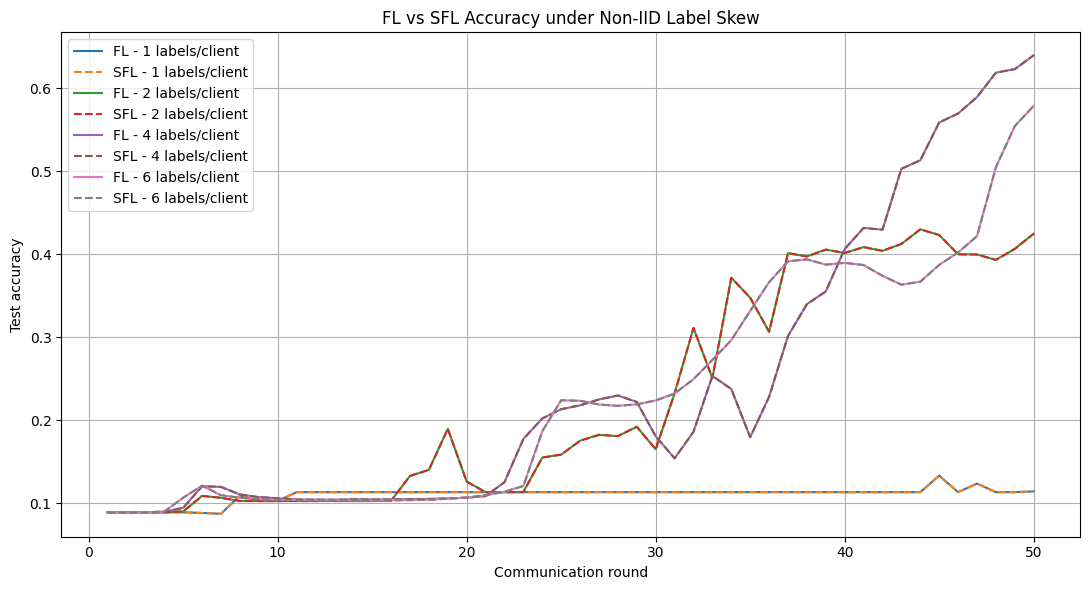

Saved accuracy plot to: results/plots/fl_vs_sfl_mnist_noniid_1_2_4_6_labels_accuracy_50_rounds.png


In [38]:
accuracy_plot_path = os.path.join(
    PLOTS_DIR,
    f"fl_vs_sfl_mnist_noniid_1_2_4_6_labels_accuracy_{ROUNDS}_rounds.png",
)

plt.figure(figsize=(11, 6))

for labels_per_client in LABELS_PER_CLIENT_LIST:
    df = combined_results_df[combined_results_df["labels_per_client"] == labels_per_client]
    plt.plot(df["round"], df["fl_test_accuracy"], label=f"FL - {labels_per_client} labels/client")
    plt.plot(df["round"], df["sfl_test_accuracy"], linestyle="--", label=f"SFL - {labels_per_client} labels/client")

plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("FL vs SFL Accuracy under Non-IID Label Skew")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(accuracy_plot_path, dpi=200)
plt.show()

print("Saved accuracy plot to:", accuracy_plot_path)


## 17. Plot loss for all settings

This plot compares the global test loss for FL and SFL across the different label-skew settings.


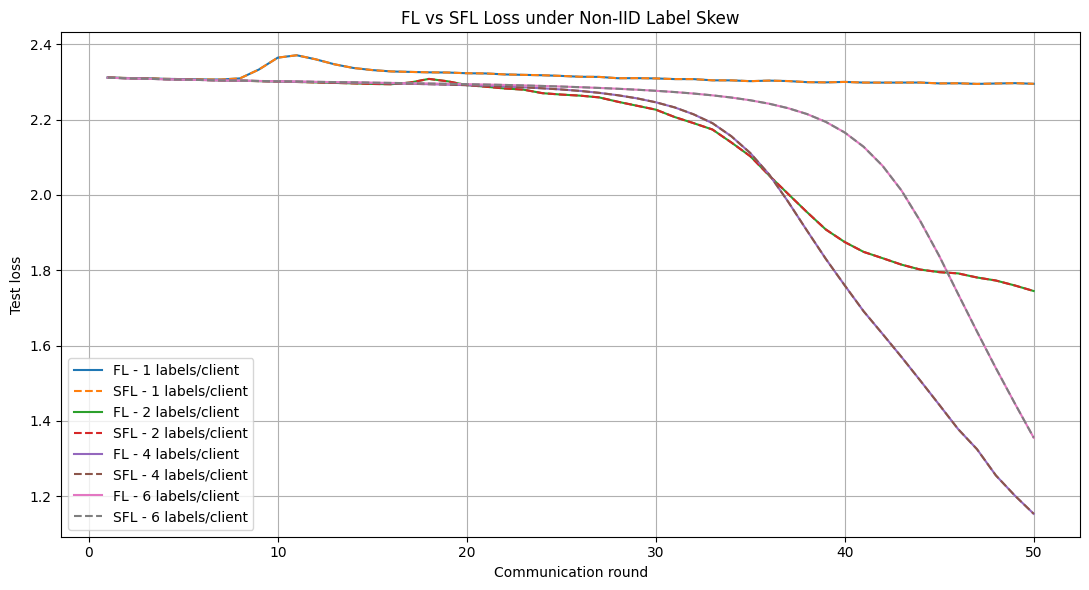

Saved loss plot to: results/plots/fl_vs_sfl_mnist_noniid_1_2_4_6_labels_loss_50_rounds.png


In [39]:
loss_plot_path = os.path.join(
    PLOTS_DIR,
    f"fl_vs_sfl_mnist_noniid_1_2_4_6_labels_loss_{ROUNDS}_rounds.png",
)

plt.figure(figsize=(11, 6))

for labels_per_client in LABELS_PER_CLIENT_LIST:
    df = combined_results_df[combined_results_df["labels_per_client"] == labels_per_client]
    plt.plot(df["round"], df["fl_test_loss"], label=f"FL - {labels_per_client} labels/client")
    plt.plot(df["round"], df["sfl_test_loss"], linestyle="--", label=f"SFL - {labels_per_client} labels/client")

plt.xlabel("Communication round")
plt.ylabel("Test loss")
plt.title("FL vs SFL Loss under Non-IID Label Skew")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved loss plot to:", loss_plot_path)


## 18. Final-round summary table

This table keeps only the final round of each experiment. It is useful for the README, report, and supervisor update.


In [40]:
final_summary_df = (
    combined_results_df
    .sort_values(["labels_per_client", "round"])
    .groupby("labels_per_client")
    .tail(1)
    [[
        "labels_per_client",
        "round",
        "optimizer",
        "fl_test_accuracy",
        "sfl_test_accuracy",
        "fl_test_loss",
        "sfl_test_loss",
        "fl_minus_sfl_accuracy",
        "global_l2_distance_fl_vs_sfl",
        "weights_dir",
    ]]
    .reset_index(drop=True)
)

summary_csv_path = os.path.join(
    RESULTS_CSV_DIR,
    f"fl_vs_sfl_mnist_noniid_final_summary_{ROUNDS}_rounds.csv",
)
final_summary_df.to_csv(summary_csv_path, index=False)

display(final_summary_df)
print("Saved final summary CSV to:", summary_csv_path)


,labels_per_client,round,optimizer,fl_test_accuracy,sfl_test_accuracy,fl_test_loss,sfl_test_loss,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl,weights_dir
0,1,50,SGD,0.1144,0.1144,2.295299,2.295299,0.0,0.0,results/weights/fl_vs_sfl_noniid_label_skew/la...
1,2,50,SGD,0.4249,0.4249,1.744850,1.744850,0.0,0.0,results/weights/fl_vs_sfl_noniid_label_skew/la...
2,4,50,SGD,0.6400,0.6400,1.153104,1.153104,0.0,0.0,results/weights/fl_vs_sfl_noniid_label_skew/la...
3,6,50,SGD,0.5789,0.5789,1.355248,1.355248,0.0,0.0,results/weights/fl_vs_sfl_noniid_label_skew/la...


Saved final summary CSV to: results/csv/fl_vs_sfl_mnist_noniid_final_summary_50_rounds.csv


## 19. Inline result tables for each non-IID setting

This cell shows the **last five rounds** for each label-skew setting. This makes the notebook easier to review without opening the saved CSV files manually.

The key columns are:

- `fl_test_accuracy`: global FL accuracy after aggregation
- `sfl_test_accuracy`: reconstructed global SFL accuracy after aggregation
- `global_l2_distance_fl_vs_sfl`: checks whether FL and SFL weights remain equivalent


In [41]:
# Display the last five rounds for each labels/client setting.
# This gives a quick inline view of whether accuracy improved by the end of training.
for labels_per_client in LABELS_PER_CLIENT_LIST:
    print("=" * 80)
    print(f"Last 5 rounds for {labels_per_client} labels/client")
    print("=" * 80)

    display(
        combined_results_df[combined_results_df["labels_per_client"] == labels_per_client]
        [[
            "round",
            "learning_rate",
            "fl_test_accuracy",
            "sfl_test_accuracy",
            "fl_test_loss",
            "sfl_test_loss",
            "fl_minus_sfl_accuracy",
            "global_l2_distance_fl_vs_sfl",
        ]]
        .tail(5)
        .reset_index(drop=True)
    )


Last 5 rounds for 1 labels/client


,round,learning_rate,fl_test_accuracy,sfl_test_accuracy,fl_test_loss,sfl_test_loss,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl
0,46,0.005,0.1135,0.1135,2.296704,2.296704,0.0,0.0
1,47,0.005,0.1238,0.1238,2.295018,2.295018,0.0,0.0
2,48,0.005,0.1135,0.1135,2.296109,2.296109,0.0,0.0
3,49,0.005,0.1135,0.1135,2.297021,2.297021,0.0,0.0
4,50,0.005,0.1144,0.1144,2.295299,2.295299,0.0,0.0


Last 5 rounds for 2 labels/client


,round,learning_rate,fl_test_accuracy,sfl_test_accuracy,fl_test_loss,sfl_test_loss,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl
0,46,0.005,0.4001,0.4001,1.791659,1.791659,0.0,0.0
1,47,0.005,0.3999,0.3999,1.780807,1.780807,0.0,0.0
2,48,0.005,0.3934,0.3934,1.772740,1.772740,0.0,0.0
3,49,0.005,0.4067,0.4067,1.759617,1.759617,0.0,0.0
4,50,0.005,0.4249,0.4249,1.744850,1.744850,0.0,0.0


Last 5 rounds for 4 labels/client


,round,learning_rate,fl_test_accuracy,sfl_test_accuracy,fl_test_loss,sfl_test_loss,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl
0,46,0.005,0.5698,0.5698,1.378117,1.378117,0.0,0.0
1,47,0.005,0.5896,0.5896,1.324664,1.324664,0.0,0.0
2,48,0.005,0.6190,0.6190,1.254963,1.254963,0.0,0.0
3,49,0.005,0.6233,0.6233,1.201589,1.201589,0.0,0.0
4,50,0.005,0.6400,0.6400,1.153104,1.153104,0.0,0.0


Last 5 rounds for 6 labels/client


,round,learning_rate,fl_test_accuracy,sfl_test_accuracy,fl_test_loss,sfl_test_loss,fl_minus_sfl_accuracy,global_l2_distance_fl_vs_sfl
0,46,0.005,0.4024,0.4024,1.736874,1.736874,0.0,0.0
1,47,0.005,0.4220,0.4220,1.637110,1.637110,0.0,0.0
2,48,0.005,0.5050,0.5050,1.539811,1.539811,0.0,0.0
3,49,0.005,0.5547,0.5547,1.446404,1.446404,0.0,0.0
4,50,0.005,0.5789,0.5789,1.355248,1.355248,0.0,0.0


## 20. Best accuracy table

This cell finds the **best round** for FL and SFL for each non-IID setting. Sometimes the best accuracy occurs before the final round, especially under unstable non-IID training.


In [42]:
best_rows = []

for labels_per_client in LABELS_PER_CLIENT_LIST:
    df = combined_results_df[combined_results_df["labels_per_client"] == labels_per_client].copy()

    # idxmax returns the row index where the accuracy is highest.
    best_fl_idx = df["fl_test_accuracy"].idxmax()
    best_sfl_idx = df["sfl_test_accuracy"].idxmax()

    best_rows.append({
        "labels_per_client": labels_per_client,
        "best_fl_round": int(combined_results_df.loc[best_fl_idx, "round"]),
        "best_fl_accuracy": float(combined_results_df.loc[best_fl_idx, "fl_test_accuracy"]),
        "best_sfl_round": int(combined_results_df.loc[best_sfl_idx, "round"]),
        "best_sfl_accuracy": float(combined_results_df.loc[best_sfl_idx, "sfl_test_accuracy"]),
        "final_fl_accuracy": float(final_summary_df.loc[final_summary_df["labels_per_client"] == labels_per_client, "fl_test_accuracy"].iloc[0]),
        "final_sfl_accuracy": float(final_summary_df.loc[final_summary_df["labels_per_client"] == labels_per_client, "sfl_test_accuracy"].iloc[0]),
    })

best_accuracy_df = pd.DataFrame(best_rows)

best_accuracy_csv_path = os.path.join(
    RESULTS_CSV_DIR,
    f"fl_vs_sfl_mnist_noniid_best_accuracy_summary_{ROUNDS}_rounds.csv",
)
best_accuracy_df.to_csv(best_accuracy_csv_path, index=False)

display(best_accuracy_df)
print("Saved best accuracy summary to:", best_accuracy_csv_path)


,labels_per_client,best_fl_round,best_fl_accuracy,best_sfl_round,best_sfl_accuracy,final_fl_accuracy,final_sfl_accuracy
0,1,45,0.1334,45,0.1334,0.1144,0.1144
1,2,44,0.4302,44,0.4302,0.4249,0.4249
2,4,50,0.6400,50,0.6400,0.6400,0.6400
3,6,50,0.5789,50,0.5789,0.5789,0.5789


Saved best accuracy summary to: results/csv/fl_vs_sfl_mnist_noniid_best_accuracy_summary_50_rounds.csv


## 21. Automatic per-setting accuracy plots

This cell creates one accuracy plot for each labels/client setting. These plots are easier to read than one crowded combined plot.


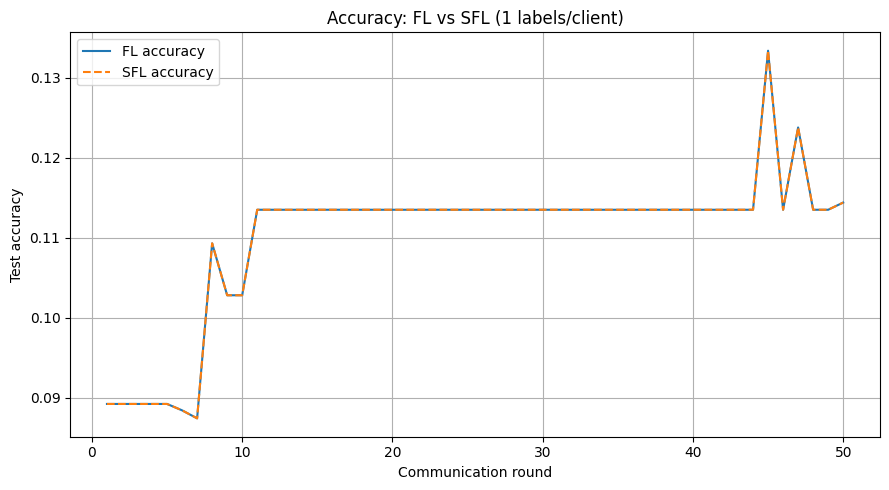

Saved: results/plots/fl_vs_sfl_mnist_noniid_1_labels_per_client_accuracy_50_rounds.png


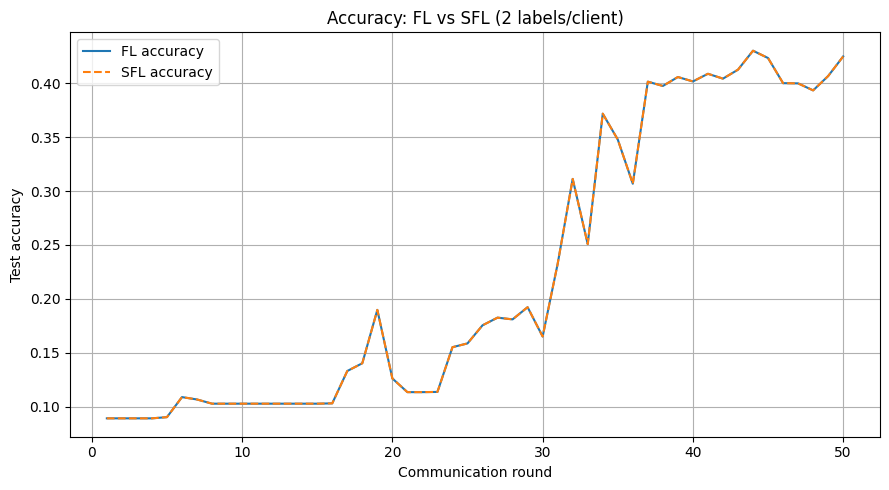

Saved: results/plots/fl_vs_sfl_mnist_noniid_2_labels_per_client_accuracy_50_rounds.png


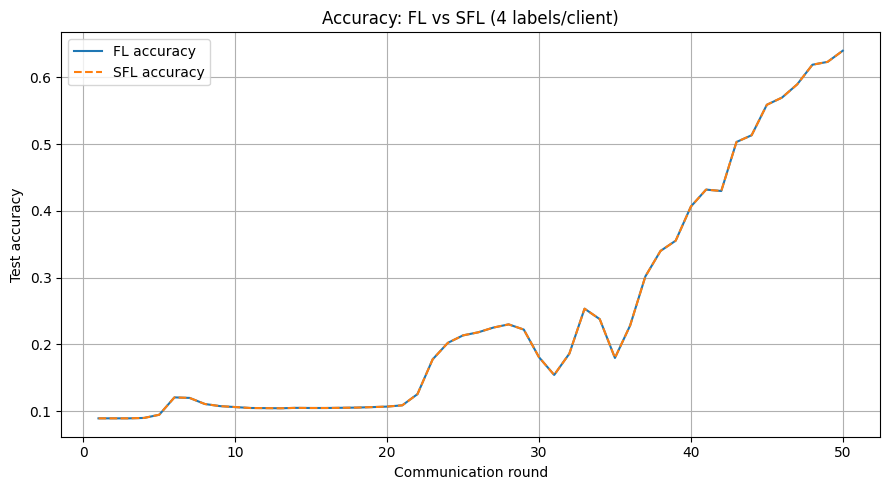

Saved: results/plots/fl_vs_sfl_mnist_noniid_4_labels_per_client_accuracy_50_rounds.png


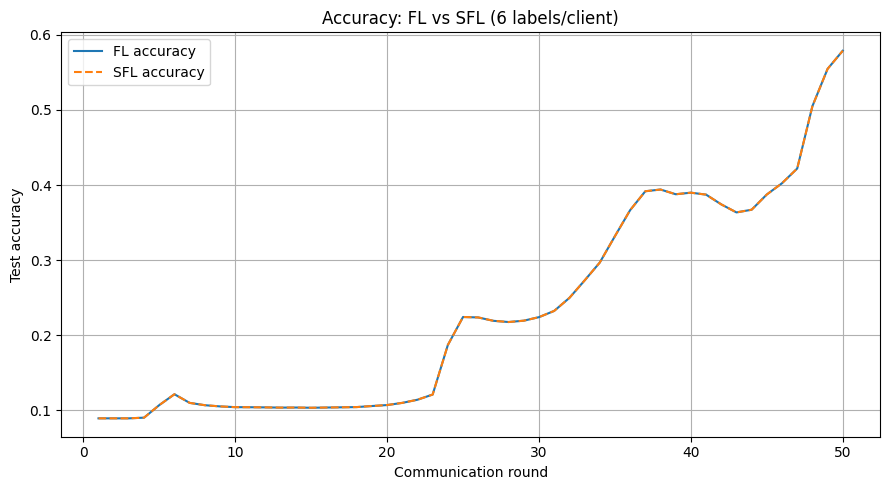

Saved: results/plots/fl_vs_sfl_mnist_noniid_6_labels_per_client_accuracy_50_rounds.png


In [43]:
per_setting_accuracy_paths = []

for labels_per_client in LABELS_PER_CLIENT_LIST:
    df = combined_results_df[combined_results_df["labels_per_client"] == labels_per_client]

    plot_path = os.path.join(
        PLOTS_DIR,
        f"fl_vs_sfl_mnist_noniid_{labels_per_client}_labels_per_client_accuracy_{ROUNDS}_rounds.png",
    )
    per_setting_accuracy_paths.append(plot_path)

    plt.figure(figsize=(9, 5))

    # Solid line = FL; dashed line = SFL.
    plt.plot(df["round"], df["fl_test_accuracy"], label="FL accuracy")
    plt.plot(df["round"], df["sfl_test_accuracy"], linestyle="--", label="SFL accuracy")

    plt.xlabel("Communication round")
    plt.ylabel("Test accuracy")
    plt.title(f"Accuracy: FL vs SFL ({labels_per_client} labels/client)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved:", plot_path)


## 22. L2 drift visualization

The L2 distance compares the global FL weights against the reconstructed global SFL weights. For the equivalence design, this should remain very close to zero. If it grows, it means the FL and SFL implementations are no longer training equivalently.


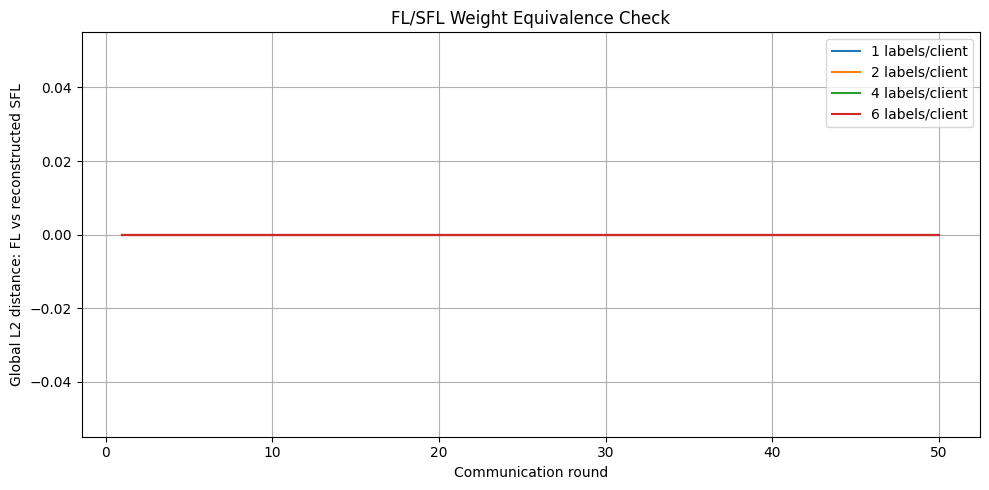

Saved L2 drift plot to: results/plots/fl_vs_sfl_mnist_noniid_l2_distance_50_rounds.png


In [44]:
l2_plot_path = os.path.join(
    PLOTS_DIR,
    f"fl_vs_sfl_mnist_noniid_l2_distance_{ROUNDS}_rounds.png",
)

plt.figure(figsize=(10, 5))

for labels_per_client in LABELS_PER_CLIENT_LIST:
    df = combined_results_df[combined_results_df["labels_per_client"] == labels_per_client]

    # This line should stay near zero when FL and SFL are equivalent.
    plt.plot(
        df["round"],
        df["global_l2_distance_fl_vs_sfl"],
        label=f"{labels_per_client} labels/client",
    )

plt.xlabel("Communication round")
plt.ylabel("Global L2 distance: FL vs reconstructed SFL")
plt.title("FL/SFL Weight Equivalence Check")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(l2_plot_path, dpi=200)
plt.show()

print("Saved L2 drift plot to:", l2_plot_path)


## 23. Accuracy improvement from 1 to 2, 4, and 6 labels/client

This cell creates a bar chart using the final-round accuracy values. It directly shows how performance changes as each client receives more label diversity.


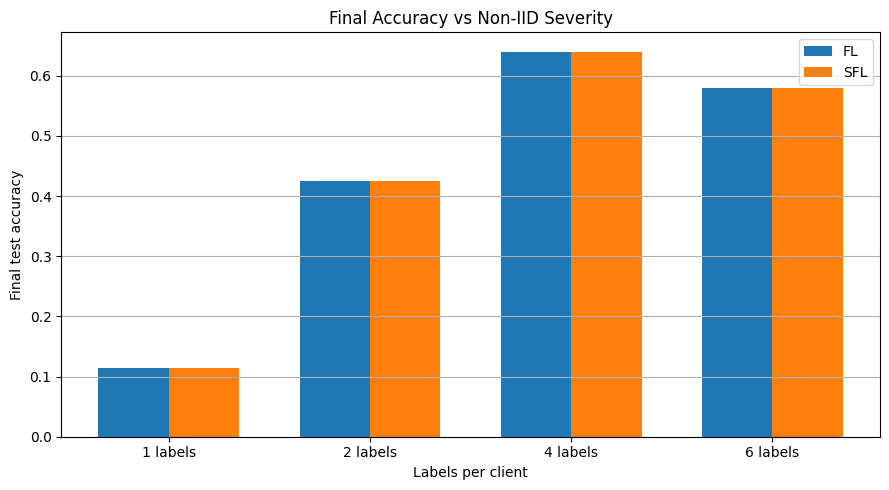

Saved final accuracy bar chart to: results/plots/fl_vs_sfl_mnist_noniid_final_accuracy_bar_50_rounds.png


In [45]:
final_accuracy_bar_path = os.path.join(
    PLOTS_DIR,
    f"fl_vs_sfl_mnist_noniid_final_accuracy_bar_{ROUNDS}_rounds.png",
)

x = np.arange(len(final_summary_df))
width = 0.35

plt.figure(figsize=(9, 5))

# Bars use final-round accuracies for each non-IID severity.
plt.bar(x - width / 2, final_summary_df["fl_test_accuracy"], width, label="FL")
plt.bar(x + width / 2, final_summary_df["sfl_test_accuracy"], width, label="SFL")

plt.xticks(x, [f"{int(v)} labels" for v in final_summary_df["labels_per_client"]])
plt.xlabel("Labels per client")
plt.ylabel("Final test accuracy")
plt.title("Final Accuracy vs Non-IID Severity")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.savefig(final_accuracy_bar_path, dpi=200)
plt.show()

print("Saved final accuracy bar chart to:", final_accuracy_bar_path)


## 24. Report-ready interpretation

This cell generates a longer report paragraph using the actual numeric results from the run. After running the notebook, copy this text into your thesis notes, README, or supervisor update.


In [46]:
report_text_lines = []
report_text_lines.append("# Report section: FL vs SFL under non-IID label skew")
report_text_lines.append("")
report_text_lines.append(
    f"This experiment compared Federated Learning (FL) and Split Federated Learning (SFL) on MNIST using {NUM_CLIENTS} clients over {ROUNDS} communication rounds. "
    f"The non-IID severity was varied by assigning each client 1, 2, 4, or 6 labels. "
    f"The optimizer was {OPTIMIZER_NAME} with a base learning rate of {LEARNING_RATE}. "
    f"The global model was evaluated on the full MNIST test set after every aggregation round."
)
report_text_lines.append("")
report_text_lines.append("## Final-round results")

for _, row in final_summary_df.iterrows():
    report_text_lines.append(
        f"- {int(row['labels_per_client'])} labels/client: "
        f"FL accuracy = {row['fl_test_accuracy']:.4f}, "
        f"SFL accuracy = {row['sfl_test_accuracy']:.4f}, "
        f"FL-SFL accuracy difference = {row['fl_minus_sfl_accuracy']:.6f}, "
        f"global L2 distance = {row['global_l2_distance_fl_vs_sfl']:.6f}."
    )

report_text_lines.append("")
report_text_lines.append("## Best observed accuracy")
for _, row in best_accuracy_df.iterrows():
    report_text_lines.append(
        f"- {int(row['labels_per_client'])} labels/client: "
        f"best FL accuracy = {row['best_fl_accuracy']:.4f} at round {int(row['best_fl_round'])}; "
        f"best SFL accuracy = {row['best_sfl_accuracy']:.4f} at round {int(row['best_sfl_round'])}."
    )

report_text_lines.append("")
report_text_lines.append("## Interpretation")
report_text_lines.append(
    "The one-label-per-client setting is an extreme non-IID case because each client only observes one digit class. "
    "In this setting, plain FedAvg is expected to struggle because each local update is strongly biased toward a single class, causing client drift and poor global generalisation. "
    "The 2, 4, and 6 labels/client settings progressively reduce the severity of the label skew, so accuracy should generally improve as each client sees more class diversity."
)
report_text_lines.append(
    "The L2 distance between FL and reconstructed SFL global weights is used as an implementation-equivalence check. "
    "If this value remains close to zero, the SFL Design 1 implementation is behaving equivalently to the FL baseline under the same data split, batch order, optimizer, learning rate, and initial weights."
)
report_text_lines.append(
    "These baseline results are important before adding poisoning attacks. They show the normal behaviour of FL and SFL under different non-IID severities, which can later be compared against attacked and defended scenarios."
)

report_text = "
".join(report_text_lines)

report_ready_path = os.path.join(
    RESULTS_CSV_DIR,
    f"fl_vs_sfl_mnist_noniid_report_ready_section_{ROUNDS}_rounds.md",
)
with open(report_ready_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("
Saved report-ready markdown to:", report_ready_path)


SyntaxError: unterminated string literal (detected at line 46) (1885245286.py, line 46)

## 25. Short report text for README or thesis notes

This cell writes a short summary text file that you can copy into your README or thesis progress notes.


In [ ]:
report_lines = [
    "Experiment: FL vs SFL under MNIST non-IID label-skew settings.",
    "",
    f"Dataset: MNIST.",
    f"Clients: {NUM_CLIENTS}.",
    f"Communication rounds: {ROUNDS}.",
    f"Local epochs per client per round: {LOCAL_EPOCHS}.",
    f"Optimizer: {OPTIMIZER_NAME}.",
    f"Base learning rate: {LEARNING_RATE}.",
    f"Learning-rate decay enabled: {USE_LR_DECAY}.",
    "",
    "The experiment compares 1, 2, 4, and 6 labels per client. The one-label-per-client case represents the most extreme non-IID setting and is expected to be the hardest for plain FedAvg. The global model is evaluated on the full MNIST test set after every aggregation round.",
    "",
    "Final-round results:",
]

for _, row in final_summary_df.iterrows():
    report_lines.append(
        f"- {int(row['labels_per_client'])} labels/client: "
        f"FL accuracy={row['fl_test_accuracy']:.4f}, "
        f"SFL accuracy={row['sfl_test_accuracy']:.4f}, "
        f"L2 distance={row['global_l2_distance_fl_vs_sfl']:.6f}."
    )

report_lines += [
    "",
    "Interpretation note:",
    "If FL and SFL remain very close, this supports the equivalence of the implemented SFL Design 1 and the FL baseline. If accuracy improves when moving from 1 label/client to 2, 4, and 6 labels/client, this demonstrates how increasing data diversity at each client reduces the difficulty caused by non-IID label skew.",
]

summary_text = "\n".join(report_lines)
summary_path = os.path.join(
    RESULTS_CSV_DIR,
    f"fl_vs_sfl_mnist_noniid_report_summary_{ROUNDS}_rounds.txt",
)

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved report summary to:", summary_path)

## 26. Where the files are saved

After running the notebook, the results are saved in the following locations.


In [ ]:
print("Per-setting CSV files:")
for labels_per_client in LABELS_PER_CLIENT_LIST:
    print(
        " -",
        os.path.join(
            RESULTS_CSV_DIR,
            f"fl_vs_sfl_mnist_noniid_{labels_per_client}_labels_per_client_{ROUNDS}_rounds.csv",
        )
    )

print("\nCombined CSV:")
print(" -", combined_csv_path)

print("\nFinal summary CSV:")
print(" -", summary_csv_path)

print("\nPlots:")
print(" -", accuracy_plot_path)
print(" -", loss_plot_path)

print("\nWeights folders:")
for labels_per_client in LABELS_PER_CLIENT_LIST:
    print(" -", os.path.join(WEIGHTS_BASE_DIR, f"labels_{labels_per_client}_per_client"))